###                MACHINE LEARNING BOOTCAMP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalization(x):
 mu=np.mean(x,axis=0)
 stnd=np.std(x,axis=0)
 stnd=np.where(stnd==0,1e-10,stnd)
 return mu,stnd

In [3]:
def compute_cost(x,y,w,b,m,lambda_,ch):  
 cost = 0.0
 f_wb= np.dot(x,w.T)+b
 if(ch==1):
  f=(1.0/(1+np.exp(-np.clip(f_wb,1e-15,1-1e-15))))
  f = np.where(f == 1, 1-1e-10,f)
  f = np.where(f == 0, 1e-10, f)
  cost=(-y.T*np.log(f) - (1-y.T)*np.log(1-f)).sum()
 else:
  cost = (((f_wb-y.T)**2).sum())/2
 cost+=(lambda_*((w**2).sum()))/2
 cost = cost/m
 return cost

In [4]:
def gradient_descent(x,y,w,b,alpha,itrns,lambda_,ch):
 m,n=x.shape
 J_history=[]
 for i in range(itrns):
   dJ_dw=np.zeros((n,))
   dJ_db=0.
   f=(np.dot(x,w.T)+b)
   if(ch==1):
    f=(1.0/(1+np.exp(-f))).T
   e=f-y
   dJ_dw=np.dot(e,x)+lambda_*w
   dJ_db+=e.sum()
   dJ_dw=dJ_dw/m
   dJ_db=dJ_db/m
   w=w-alpha*dJ_dw
   b=b-alpha*dJ_db
   if i<10000:
     cost=compute_cost(x,y,w,b,m,lambda_,ch)
     if i%(itrns/10)==0:
       print (f"Iteration {i}: Cost {cost}")
   J_history.append(cost)
 return w,b,cost,J_history

In [5]:
def R2Score(y,cost):
 rss=((y-np.mean(y))**2).sum()
 tss=cost*2*m
 r2s=1-tss/rss
 print(f"R2 Score: {r2s}")

# Linear Regression

Iteration 0: Cost 42237295.40503085
Iteration 50: Cost 2.4437417431307416
Iteration 100: Cost 0.0050571044737440455
Iteration 150: Cost 0.005056309245492332
Iteration 200: Cost 0.005056309245189225
Iteration 250: Cost 0.005056309245189817
Iteration 300: Cost 0.005056309245190002
Iteration 350: Cost 0.005056309245190002
Iteration 400: Cost 0.005056309245190002
Iteration 450: Cost 0.005056309245190002
w,b found by gradient descent for training set:[2.20094926e+01 3.31780345e+01 9.97827845e+00 6.05503562e+00
 1.75801446e+02 3.29767798e+02 2.53401879e+02 9.01327122e+02
 4.34883141e+02 8.38522040e+01 1.21247347e+02 1.60707878e+03
 1.67724165e+03 1.31519197e+03 6.01314028e+02 1.05787585e+04
 5.03735178e+02 6.78271719e+02 3.17145335e+03 2.30705235e+02]55.501275796659286
R2 Score for training set : 
R2 Score: 0.9999999999230842


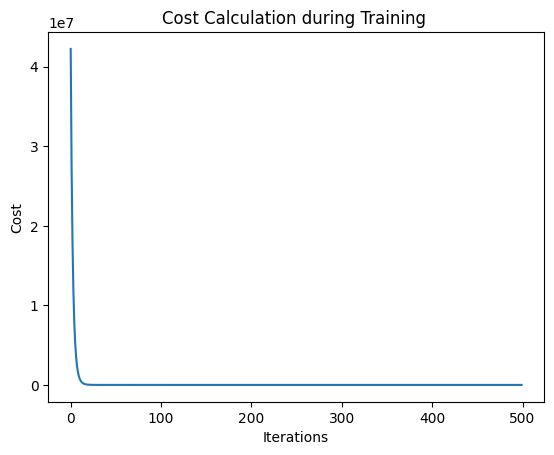

R2 Score for validation set : 
R2 Score: 0.9999999996872431
ID : 14189.0   cost: -5420.002370861825
ID : 14742.0   cost: 17534.739898481886
ID : 13905.0   cost: 4663.85377531474
ID : 10072.0   cost: 2675.4427817486007
ID : 14879.0   cost: 3383.703137911791
ID : 13815.0   cost: 25792.109403120307
ID : 19697.0   cost: 24862.322549045588
ID : 17494.0   cost: 2612.522710798255
ID : 16252.0   cost: -9793.035642993189
ID : 16260.0   cost: 12398.930436618737
ID : 10947.0   cost: 16657.902468673907
ID : 11538.0   cost: -7509.207600165964
ID : 10851.0   cost: -18323.47311841396
ID : 12313.0   cost: -7973.950335926338
ID : 14644.0   cost: -7547.603057999557
ID : 17497.0   cost: 684.3204399191195
ID : 12965.0   cost: -10146.12828336219
ID : 17746.0   cost: 4748.582079017351
ID : 13264.0   cost: 14162.919472685664
ID : 15763.0   cost: -23796.376291824563
ID : 13170.0   cost: -10563.81997927359
ID : 14479.0   cost: 24220.157814931612
ID : 10346.0   cost: -8317.57582436399
ID : 18970.0   cost: 5541.

In [16]:
 df=np.array(pd.read_csv("Lineardata_train.csv"))
 np.random.shuffle(df)
 x=df[:,1:]
 m,n = x.shape

 a=int(80/100*m)
 x_train=x[:a,:]
 mu,stnd=normalization(x_train)
 x_train=(x_train-mu)/stnd
 x_validate=x[a:,:]
 x_validate=(x_validate-mu)/stnd
 m,n=x_train.shape
 y=df[:,0]
 y_train=y[:a]
 y_validate=y[a:]
 w=np.random.randn(n,)
 b=np.random.rand()
 alpha=1.8
 itrns=500
 lambda_=0

 w,b,cost,cost_history=gradient_descent(x_train,y_train,w,b,alpha,itrns,lambda_,0)
 print(f"w,b found by gradient descent for training set:{w}{b}")
 print(f"R2 Score for training set : ")
 R2Score(y_train,cost)

 plt.plot(cost_history) plt.xlabel('Iterations')  plt.ylabel('Cost' )  plt.title('Cost Calculation during Training ' )  plt.show()

 print(f"R2 Score for validation set : ")
 R2Score(y_validate,cost) 
 df1=np.array(pd.read_csv("Lineardata_test.csv"))
 x1=df1[:,1:]
 x1=(x1-mu)/stnd
 y1=np.dot(x1,w.T)+b
 Id=df1[:,0]
 for i in range(len(Id)):
  print(f"ID : {Id[i]}   cost: {y1.T[i]}")

# Logistic Regression

dfl=np.array(pd.read_csv("Classification_train.csv"))
np.random.shuffle(dfl)
xl=dfl[:,1:]
m,n = xl.shape
a=int(70/100*m)
xl_train=xl[:a,:]

mu,stnd=normalization(xl_train)
xl_train=(xl_train-mu)/stnd
xl_validate=xl[a:,:]
xl_validate=(xl_validate-mu)/stnd
m,n=xl_train.shape

yl=dfl[:,0]
yl_train=yl[:a]
yl_validate=yl[a:]
w=np.random.randn(n,)
b=np.random.rand()
alpha=4.8
itrns=1000
lambda_=0

binary_labels = (yl_train== np.arange(len(np.unique(yl_train)))[:, None]).astype(float)
w,b,cost,cost_history=gradient_descent(xl_train,binary_labels,w,b,alpha,itrns,lambda_,1)
print(f"w,b found by gradient descent for training set:{w}{b}")
ynew=1.0/(1+np.exp(-(np.dot(xl_train,w.T)+b)))
ynew=np.argmax(ynew,axis=1)
accuracy = np.mean(ynew == yl_train)
print(f"Accuracy for training set: {accuracy}")

plt.plot(cost_history)
plt.xlabel('Iterations') 
plt.ylabel('Cost' ) 
plt.title('Cost Calculation during Training ' ) 
plt.show()

ynew=1.0/(1+np.exp(-(np.dot(xl_validate,w.T)+b)))
ynew=np.argmax(ynew,axis=1)
accuracy = np.mean(ynew == yl_validate)
print(f"Accuracy for validation set: {accuracy}")

df1=np.array(pd.read_csv("Classification_test.csv"))
x1=df1[:,1:]
x1=(x1-mu)/stnd
y1=np.dot(x1,w.T)+b
y1=1.0/(1+np.exp(np.clip(-y1, 1e-15, 1 - 1e-15)))
y1=np.argmax(y1,axis=1)
Id=df1[:,0]
for i in range(len(Id)):
 print(f"ID : {Id[i]}   label: {y1.T[i]}") 